-- SQL code

-- ranked male _bilirubin_ values for qq plot
select 
    row_number() over (order by _bilirubin_) as rank_males,
    _bilirubin_ as maleBilirubin
from hepatitis
where _sex_ = 1 
  and _bilirubin_ is not null
order by _bilirubin_;

-- ranked female _bilirubin_ values for qq plot
select 
    row_number() over (order by _bilirubin_) as rank_females,
    _bilirubin_ as female_bilirubin
from hepatitis
where _sex_ = 2 
  and _bilirubin_ is not null
order by _bilirubin_;

-- Compare bilirubin distribution 
-- between males and females using quantile buckets
=
-- create quantile buckets separately for males i.e. sex = 1
with males as (
    select 
        NTILE(50) OVER (order by bilirubin) as q,  
        -- divide male data into up to 50 ranked buckets i.e. quantiles 
        -- but may be fewer if data is small

        bilirubin
    from hepatitis
    where sex = 1 
      and bilirubin is not null                 
      -- keep only non-null i.e. valid bilirubin values
),

-- create quantile buckets separately for females which is sex = 2
females as (
    select 
        NTILE(50) OVER (order by bilirubin) as q,  
        -- same bucketing logic for females 
        -- i.e. relative ranking within female group

        bilirubin
    from hepatitis
    where sex = 2 
      and bilirubin is not null
)

-- combine male and female buckets and compute averages
select 
    m.q as quantilebucket,                        
    -- bucket number i.e. relative rank group

    AVG(m.bilirubin) as male_bilirubin,           
    -- average bilirubin within each male bucket

    AVG(f.bilirubin) as female_bilirubin         
    -- average bilirubin within each female bucket

from males m
join females f 
    on f.q = m.q                                  
    -- align male and female buckets by same quantile index 
    -- i.e. comparable rank positions

group by m.q
order by m.q;


-- output: one row per quantile bucket showing
--         average bilirubin for males vs females
-- useful for plotting distribution comparison

In [22]:



import pandas as pd
import matplotlib.pyplot as plt

# load your SQL outputs (CSV or direct connection)
male_df = pd.read_csv('C:/Users/ahafeez7/Downloads/780/lm2_q04/male_bilirubin.csv')
female_df = pd.read_csv('C:/Users/ahafeez7/Downloads/780/lm2_q04/female_bilirubin.csv')


# merge on rank
# if you have same name for rank column e.g., rank
#df = pd.merge(male_df, female_df, on="rank")

# if you have different names for rank column then use this code
df = pd.merge(
    male_df,
    female_df,
    left_on="rank_male",
    right_on="rank_female"
)

# QQ plot
plt.figure()
plt.scatter(df["male_bilirubin"], df["female_bilirubin"])

# 45-degree reference line
min_val = min(df["male_bilirubin"].min(), df["female_bilirubin"].min())
max_val = max(df["maleBilirubin"].max(), df["femaleBilirubin"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Male Quantiles")
plt.ylabel("Female Quantiles")
plt.title("QQ Plot: Male vs Female Bilirubin")
plt.grid()

plt.show()

KeyError: 'male_bilirubin'

<Figure size 640x480 with 0 Axes>

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "quantilebucket": list(range(1,17)),
    "male_bilirubin": [
        0.4,0.6,0.6,0.6,0.7,0.7,0.7,0.7,0.7,0.7,0.7,0.8,0.8,0.8,0.8667,0.9
    ],
    "female_bilirubin": [
        0.4,0.5,0.6,0.7,0.7,0.9,0.9,1,1,1.3,1.4,1.5,1.5,1.8,2.3,3.2
    ]
}

df = pd.DataFrame(data)

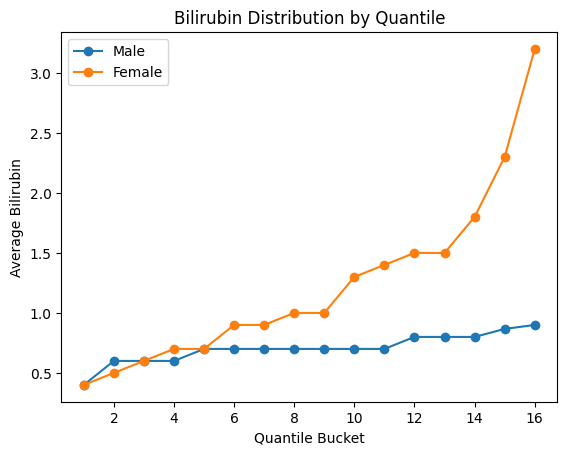

In [11]:
plt.figure()
plt.plot(df["quantilebucket"], df["male_bilirubin"], marker='o', label="Male")
plt.plot(df["quantilebucket"], df["female_bilirubin"], marker='o', label="Female")

plt.xlabel("Quantile Bucket")
plt.ylabel("Average Bilirubin")
plt.title("Bilirubin Distribution by Quantile")
plt.legend()
plt.show()

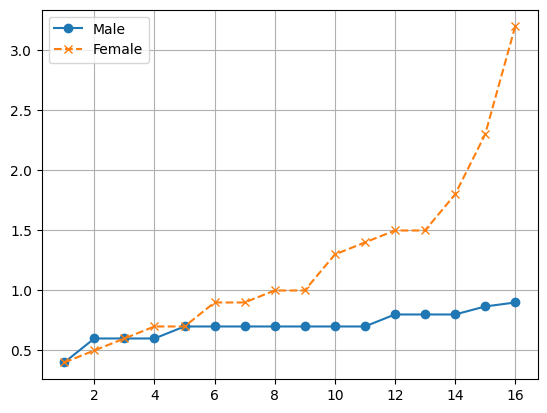

In [12]:
plt.figure()
plt.plot(df["quantilebucket"], df["male_bilirubin"], marker='o', label="Male")
plt.plot(df["quantilebucket"], df["female_bilirubin"], marker='x', linestyle='--', label="Female")
plt.legend()
plt.show()

-- SQL code
-- Compare bilirubin distribution 
-- between males and females using quantile buckets
------------------------systemetic approach-------------------------------
-- with fewer/natural buckets rather than many buckets which could be noisy and sparse
declare @m_count int = (
    select count(*) from hepatitis 
    where sex = 1 and bilirubin is not null
);

declare @f_count int = (
    select count(*) from hepatitis 
    where sex = 2 and bilirubin is not null
);

-- choose buckets based on smaller group (avoid sparse buckets) 
declare @buckets int = case 
    when @m_count < @f_count then @m_count / 5
    else @f_count / 5
end;

-- error handling - to ensure at least 1 bucket
if @buckets < 1 set @buckets = 1;

with Males as (
    select ntile(@buckets) over (order by bilirubin) as q, bilirubin
    from hepatitis
    where sex = 1 and bilirubin is not null
),
Females as (
    select ntile(@buckets) over (order by bilirubin) as q, bilirubin
    from hepatitis
    where sex = 2 and bilirubin is not null
)
select 
    m.q,
    avg(m.bilirubin) as male_bilirubin,
    avg(f.bilirubin) as female_bilirubin
from Males m
join Females f on m.q = f.q
group by m.q
order by m.q;


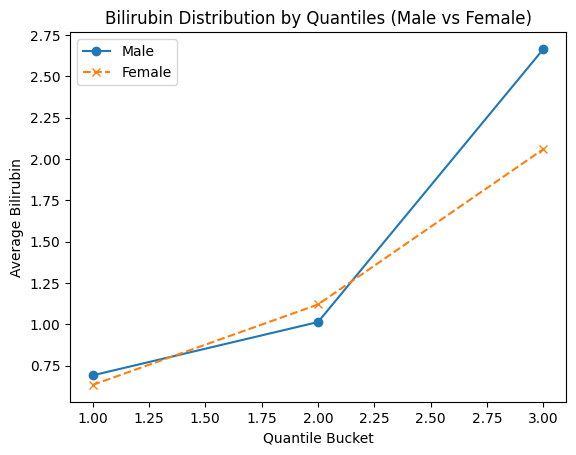

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# your results
data = {
    "q": [1, 2, 3],
    "male_bilirubin": [0.6911, 1.0136, 2.6659],
    "female_bilirubin": [0.6333, 1.1200, 2.0600]
}

df = pd.DataFrame(data)

# plot
plt.figure()
plt.plot(df["q"], df["male_bilirubin"], marker='o', label='Male')
plt.plot(df["q"], df["female_bilirubin"],marker='x', linestyle='--',label='Female')

plt.xlabel("Quantile Bucket")
plt.ylabel("Average Bilirubin")
plt.title("Bilirubin Distribution by Quantiles (Male vs Female)")
plt.legend()
plt.show()